# Análisis de la Energía — Simulación de Dinámica Molecular

**Sistema:** Tripéptido **ACE-ALA-ARG-VAL-NME** (ARV) en solución acuosa  
**Campo de fuerzas:** CHARMM27 · **Modelo de agua:** TIP3P  
**Herramienta:** GROMACS · `gmx energy`  
**Temperaturas simuladas:** 298 K y 400 K

Se analiza la evolución temporal de la **energía cinética** y la **energía total** del sistema
a las dos temperaturas de simulación (298 K y 400 K).  
Adicionalmente, se comparan los valores medios de la energía cinética con la predicción
del **teorema de equipartición** de la termodinámica estadística.

---

## 1. Importación de librerías y configuración de estilo

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import sem

# ── Estilo publicación científica ──────────────────────────────────────────────
plt.rcParams.update({
    'font.family':         'serif',
    'font.size':           11,
    'axes.labelsize':      12,
    'axes.titlesize':      12,
    'axes.linewidth':      1.2,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.major.width':   1.1,
    'ytick.major.width':   1.1,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'legend.framealpha':   0.9,
    'legend.fontsize':     10,
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
})

# Columnas de los archivos .xvg de energía: tiempo (ps) y energía (kJ/mol)
COLS = ['time_ps', 'E_kJmol']

# ── Parámetros del sistema ─────────────────────────────────────────────────────
N_ATOMS = 2634                  # Número de átomos del sistema (proteína + agua + iones)
R_GAS   = 8.314462618e-3        # Constante de los gases ideales NIST (kJ·mol⁻¹·K⁻¹)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga de datos

In [2]:
def load_xvg(filepath, col_names):
    """Lee un archivo .xvg de GROMACS ignorando cabeceras (líneas con '@' o '#')."""
    data = []
    with open(filepath) as fh:
        for line in fh:
            line = line.strip()
            if line.startswith('#') or line.startswith('@') or not line:
                continue
            data.append(list(map(float, line.split())))
    df = pd.DataFrame(data, columns=col_names)
    return df

# Energía cinética
df_kin_298 = load_xvg('energy-kinetic-298.xvg', COLS)
df_kin_400 = load_xvg('energy-kinetic-400.xvg', COLS)

# Energía total
df_total_298 = load_xvg('energy-total-298.xvg', COLS)
df_total_400 = load_xvg('energy-total-400.xvg', COLS)

print('── Energía cinética ──')
print(f'298 K → {len(df_kin_298)} frames  |  tiempo: {df_kin_298.time_ps.min():.3f} – {df_kin_298.time_ps.max():.3f} ps')
print(f'400 K → {len(df_kin_400)} frames  |  tiempo: {df_kin_400.time_ps.min():.3f} – {df_kin_400.time_ps.max():.3f} ps')
print()
print('── Energía total ──')
print(f'298 K → {len(df_total_298)} frames  |  tiempo: {df_total_298.time_ps.min():.3f} – {df_total_298.time_ps.max():.3f} ps')
print(f'400 K → {len(df_total_400)} frames  |  tiempo: {df_total_400.time_ps.min():.3f} – {df_total_400.time_ps.max():.3f} ps')

df_kin_298.head(3)

── Energía cinética ──
298 K → 2001 frames  |  tiempo: 0.000 – 2.000 ps
400 K → 2001 frames  |  tiempo: 0.000 – 2.000 ps

── Energía total ──
298 K → 2001 frames  |  tiempo: 0.000 – 2.000 ps
400 K → 2001 frames  |  tiempo: 0.000 – 2.000 ps


,time_ps,E_kJmol
0,0.000,9675.171875
1,0.001,9658.618164
2,0.002,9670.673828


## 7. Comparativa superpuesta — Energía cinética

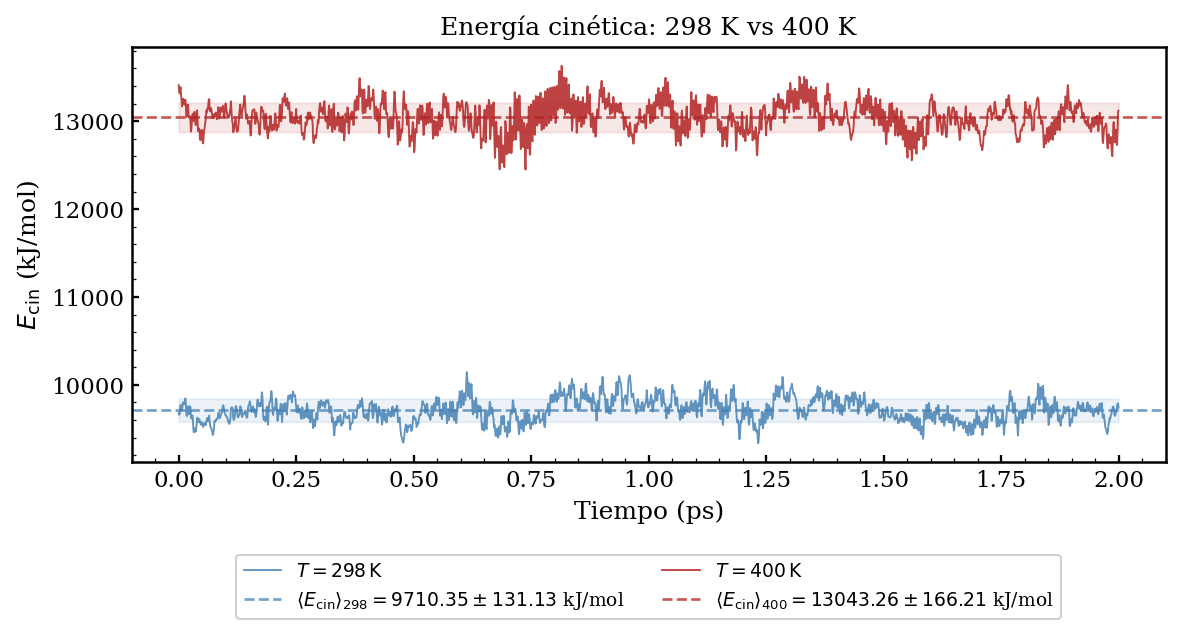

Figura guardada como energy_kinetic_comparison_overlay.png


In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for df, T, col in [(df_kin_298, 298, 'steelblue'),
                    (df_kin_400, 400, 'firebrick')]:
    mean_val = df['E_kJmol'].mean()
    std_val  = df['E_kJmol'].std()

    ax.plot(df['time_ps'], df['E_kJmol'], color=col, lw=0.9, alpha=0.85,
            label=rf'$T = {T}\,\mathrm{{K}}$')
    ax.axhline(mean_val, color=col, lw=1.3, ls='--', alpha=0.75,
               label=rf'$\langle E_{{\mathrm{{cin}}}} \rangle_{{{T}}} = {mean_val:.2f} \pm {std_val:.2f}$ kJ/mol')
    ax.fill_between(df['time_ps'],
                    mean_val - std_val, mean_val + std_val,
                    color=col, alpha=0.10)

ax.set_xlabel('Tiempo (ps)')
ax.set_ylabel('$E_{\\mathrm{cin}}$ (kJ/mol)')
ax.set_title('Energía cinética: 298 K vs 400 K')
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2, fontsize=9)

plt.tight_layout()
plt.savefig('energy_kinetic_comparison_overlay.png')
plt.show()
print('Figura guardada como energy_kinetic_comparison_overlay.png')


## 8. Comparación con la termodinámica estadística — Energía cinética

Según el **teorema de equipartición**, la energía cinética media de un sistema de
$N$ átomos clásicos a temperatura $T$ es:

$$\langle E_{\mathrm{cin}} \rangle = N \times \frac{3}{2}\, k_B T$$

donde $k_B T$ en unidades molares se obtiene con la constante de los gases ideales
$R = 8.314 \times 10^{-3}$ kJ·mol$^{-1}$·K$^{-1}$, de modo que $k_B T = R\,T$.

Para nuestro sistema ($N = 2634$ átomos):
- A **298 K**: $k_B T = 2.4777$ kJ/mol → $E_{\mathrm{cin}}^{\mathrm{teórico}} = 2634 \times \tfrac{3}{2} \times 2.4777 = 9789.43$ kJ/mol  
- A **400 K**: $k_B T = 3.3258$ kJ/mol → $E_{\mathrm{cin}}^{\mathrm{teórico}} = 2634 \times \tfrac{3}{2} \times 3.3258 = 13140.18$ kJ/mol

## 10. Evolución temporal de la energía cinética con valor teórico superpuesto

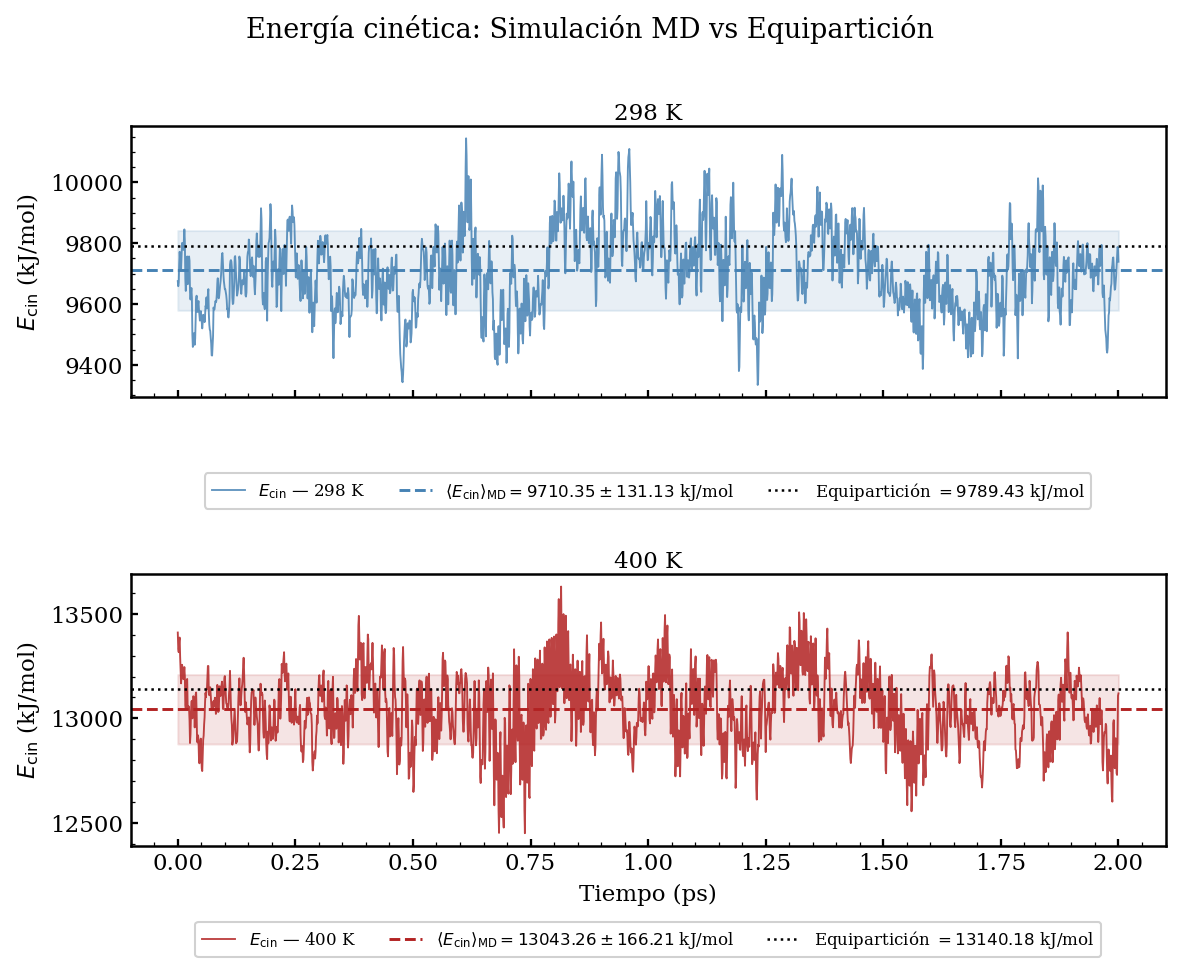

Figura guardada como energy_kinetic_with_theory.png


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True)

for ax, df, T_nom, col in zip(axes,
                               [df_kin_298, df_kin_400],
                               [298, 400],
                               ['steelblue', 'firebrick']):
    mean_val = df['E_kJmol'].mean()
    std_val  = df['E_kJmol'].std()
    kBT      = R_GAS * T_nom                 # k_B·T en kJ/mol
    E_teo    = N_ATOMS * 1.5 * kBT          # (3/2)·N·k_B·T

    ax.plot(df['time_ps'], df['E_kJmol'], color=col, lw=0.9, alpha=0.85,
            label=rf'$E_{{\mathrm{{cin}}}}$ — {T_nom} K')
    ax.axhline(mean_val, color=col, lw=1.4, ls='--',
               label=rf'$\langle E_{{\mathrm{{cin}}}} \rangle_{{\mathrm{{MD}}}} = {mean_val:.2f} \pm {std_val:.2f}$ kJ/mol')
    ax.axhline(E_teo, color='black', lw=1.2, ls=':',
               label=rf'Equipartición $= {E_teo:.2f}$ kJ/mol')
    ax.fill_between(df['time_ps'],
                    mean_val - std_val, mean_val + std_val,
                    color=col, alpha=0.12)

    ax.set_ylabel('$E_{\\mathrm{cin}}$ (kJ/mol)', fontsize=11)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.set_title(f'{T_nom} K', fontsize=11, pad=3)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=3, fontsize=8)

axes[-1].set_xlabel('Tiempo (ps)', fontsize=11)
fig.suptitle('Energía cinética: Simulación MD vs Equipartición', fontsize=13, y=1.01)
fig.align_ylabels()

plt.tight_layout()
plt.savefig('energy_kinetic_with_theory.png')
plt.show()
print('Figura guardada como energy_kinetic_with_theory.png')


## 13. Comparativa superpuesta — Energía total

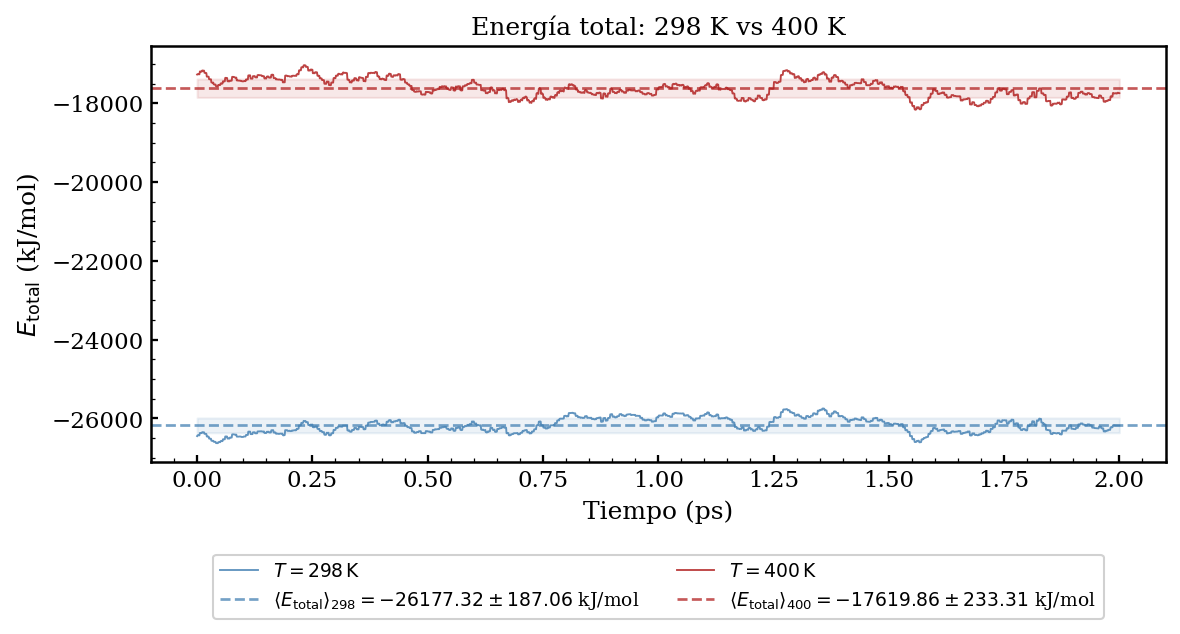

Figura guardada como energy_total_comparison_overlay.png


In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for df, T, col in [(df_total_298, 298, 'steelblue'),
                    (df_total_400, 400, 'firebrick')]:
    mean_val = df['E_kJmol'].mean()
    std_val  = df['E_kJmol'].std()

    ax.plot(df['time_ps'], df['E_kJmol'], color=col, lw=0.9, alpha=0.85,
            label=rf'$T = {T}\,\mathrm{{K}}$')
    ax.axhline(mean_val, color=col, lw=1.3, ls='--', alpha=0.75,
               label=rf'$\langle E_{{\mathrm{{total}}}} \rangle_{{{T}}} = {mean_val:.2f} \pm {std_val:.2f}$ kJ/mol')
    ax.fill_between(df['time_ps'],
                    mean_val - std_val, mean_val + std_val,
                    color=col, alpha=0.10)

ax.set_xlabel('Tiempo (ps)')
ax.set_ylabel('$E_{\\mathrm{total}}$ (kJ/mol)')
ax.set_title('Energía total: 298 K vs 400 K')
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2, fontsize=9)

plt.tight_layout()
plt.savefig('energy_total_comparison_overlay.png')
plt.show()
print('Figura guardada como energy_total_comparison_overlay.png')


## 14. Comparativa apilada — Energía total (298 K vs 400 K)

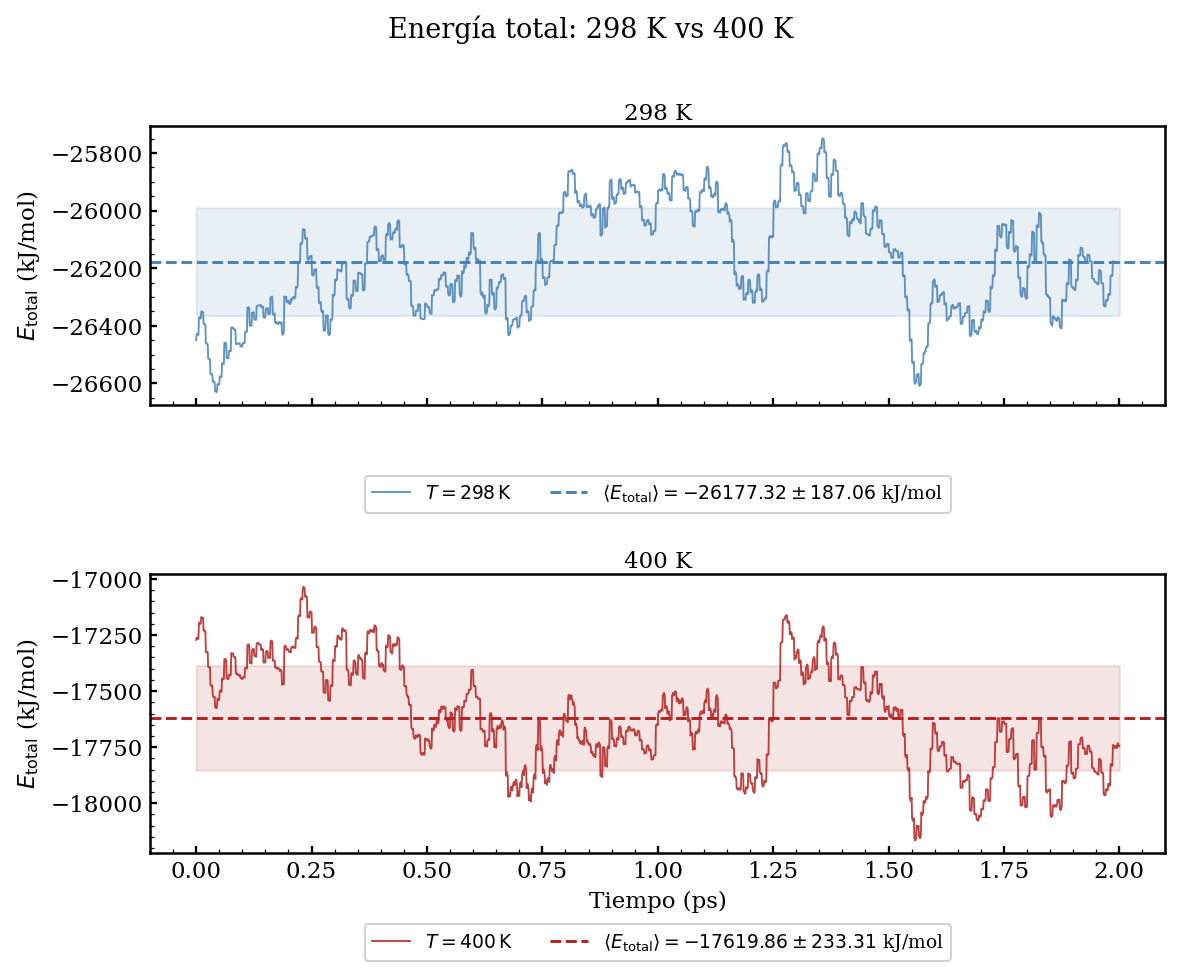

Figura guardada como energy_total_comparison_stacked.png


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True)

for ax, df, T, col in zip(axes,
                           [df_total_298, df_total_400],
                           ['298', '400'],
                           ['steelblue', 'firebrick']):
    mean_val = df['E_kJmol'].mean()
    std_val  = df['E_kJmol'].std()

    ax.plot(df['time_ps'], df['E_kJmol'], color=col, lw=0.9, alpha=0.85,
            label=rf'$T = {T}\,\mathrm{{K}}$')
    ax.axhline(mean_val, color=col, lw=1.4, ls='--',
               label=rf'$\langle E_{{\mathrm{{total}}}} \rangle = {mean_val:.2f} \pm {std_val:.2f}$ kJ/mol')
    ax.fill_between(df['time_ps'],
                    mean_val - std_val, mean_val + std_val,
                    color=col, alpha=0.12)

    ax.set_ylabel('$E_{\\mathrm{total}}$ (kJ/mol)', fontsize=11)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.set_title(f'{T} K', fontsize=11, pad=3)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=2, fontsize=9)

axes[-1].set_xlabel('Tiempo (ps)', fontsize=11)
fig.suptitle('Energía total: 298 K vs 400 K', fontsize=13, y=1.01)
fig.align_ylabels()

plt.tight_layout()
plt.savefig('energy_total_comparison_stacked.png')
plt.show()
print('Figura guardada como energy_total_comparison_stacked.png')


## 13. Resumen estadístico completo

In [7]:
final_rows = []
for df, T_nom, tipo in [
    (df_kin_298,   298, 'Cinética'),
    (df_kin_400,   400, 'Cinética'),
    (df_total_298, 298, 'Total'),
    (df_total_400, 400, 'Total'),
]:
    E = df['E_kJmol']
    row = {
        'T (K)':            T_nom,
        'Tipo':             tipo,
        '⟨E⟩ (kJ/mol)':    round(E.mean(), 2),
        'σ(E) (kJ/mol)':    round(E.std(),  2),
        'SEM (kJ/mol)':     round(sem(E),    2),
        'Min (kJ/mol)':     round(E.min(),   2),
        'Max (kJ/mol)':     round(E.max(),   2),
    }
    if tipo == 'Cinética':
        kBT   = R_GAS * T_nom                # k_B·T en kJ/mol
        E_teo = N_ATOMS * 1.5 * kBT         # (3/2)·N·k_B·T
        row['E_cin teórico (kJ/mol)'] = E_teo
        row['Error rel. (%)']         = abs(E.mean() - E_teo) / E_teo * 100
    else:
        row['E_cin teórico (kJ/mol)'] = '—'
        row['Error rel. (%)']         = '—'
    final_rows.append(row)

final_df = pd.DataFrame(final_rows)

(final_df.style
    .format({
        '⟨E⟩ (kJ/mol)':              '{:.2f}',
        'σ(E) (kJ/mol)':              '{:.2f}',
        'SEM (kJ/mol)':               '{:.2f}',
        'Min (kJ/mol)':               '{:.2f}',
        'Max (kJ/mol)':               '{:.2f}',
        'E_cin teórico (kJ/mol)':     lambda x: f'{x:.2f}' if isinstance(x, float) else x,
        'Error rel. (%)':             lambda x: f'{x:.2f}' if isinstance(x, float) else x,
    })
    .set_caption('Tabla 1. Resumen estadístico de las energías del sistema. '
                 'Para la energía cinética se incluye el valor teórico '
                 'según el teorema de equipartición.')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'),
                   ('text-align', 'left'), ('margin-bottom', '6px')]},
        {'selector': 'th',
         'props': [('background-color', '#2c3e50'), ('color', 'white'),
                   ('text-align', 'center'), ('padding', '6px 10px'),
                   ('font-size', '12px')]},
        {'selector': 'td',
         'props': [('text-align', 'center'), ('padding', '5px 10px'),
                   ('font-size', '11px')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color', '#f0f4f8')]},
        {'selector': 'tr:hover',
         'props': [('background-color', '#d6e4f0')]},
    ])
    .apply(lambda col: [
        'background-color: #eaf4fb' if v == 298 else 'background-color: #fdecea'
        for v in col
    ], subset=['T (K)'])
    .hide(axis='index')
)


T (K),Tipo,⟨E⟩ (kJ/mol),σ(E) (kJ/mol),SEM (kJ/mol),Min (kJ/mol),Max (kJ/mol),E_cin teórico (kJ/mol),Error rel. (%)
298,Cinética,9710.35,131.13,2.93,9334.20,10144.60,9789.43,0.81
400,Cinética,13043.26,166.21,3.72,12449.91,13631.00,13140.18,0.74
298,Total,-26177.32,187.06,4.18,-26629.95,-25749.34,—,—
400,Total,-17619.86,233.31,5.22,-18166.86,-17034.95,—,—
